In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Import project modules
from config import STRAINS, ATCC_GROUPINGS, antibiotics, HIERARCHICAL_GROUPINGS, HIERARCHICAL_CLASSES

def set_seed(seed=123):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(123)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR = ""
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.8.0+cu128


In [24]:
# Load the dataset
X_ref = np.load(os.path.join(DATA_DIR, "X_reference.npy"))
y_ref = np.load(os.path.join(DATA_DIR, "y_reference.npy")).astype(int)
X_te = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_te = np.load(os.path.join(DATA_DIR, "y_test.npy")).astype(int)

print("Dataset shapes:")
print(f"X_reference: {X_ref.shape}")
print(f"y_reference: {y_ref.shape}")
print(f"X_test: {X_te.shape}")
print(f"y_test: {y_te.shape}")

# Check strain distribution
print(f"\nStrain distribution in reference set:")
strain_counts = Counter(y_ref)
for strain_id, count in sorted(strain_counts.items()):
    print(f"Strain {strain_id} ({STRAINS[strain_id]}): {count} samples")

Dataset shapes:
X_reference: (60000, 1000)
y_reference: (60000,)
X_test: (3000, 1000)
y_test: (3000,)

Strain distribution in reference set:
Strain 0 (C. albicans): 2000 samples
Strain 1 (C. glabrata): 2000 samples
Strain 2 (K. aerogenes): 2000 samples
Strain 3 (E. coli 1): 2000 samples
Strain 4 (E. coli 2): 2000 samples
Strain 5 (E. faecium): 2000 samples
Strain 6 (E. faecalis 1): 2000 samples
Strain 7 (E. faecalis 2): 2000 samples
Strain 8 (E. cloacae): 2000 samples
Strain 9 (K. pneumoniae 1): 2000 samples
Strain 10 (K. pneumoniae 2): 2000 samples
Strain 11 (P. mirabilis): 2000 samples
Strain 12 (P. aeruginosa 1): 2000 samples
Strain 13 (P. aeruginosa 2): 2000 samples
Strain 14 (MSSA 1): 2000 samples
Strain 15 (MSSA 3): 2000 samples
Strain 16 (MRSA 1 (isogenic)): 2000 samples
Strain 17 (MRSA 2): 2000 samples
Strain 18 (MSSA 2): 2000 samples
Strain 19 (S. enterica): 2000 samples
Strain 20 (S. epidermidis): 2000 samples
Strain 21 (S. lugdunensis): 2000 samples
Strain 22 (S. marcescens)

In [25]:
def get_hierarchical_strains():
    """Get strain IDs that belong to MSSA or MRSA classes"""
    hierarchical_strains = [14, 15, 16, 17, 18]  # MSSA and MRSA strains
    return sorted(hierarchical_strains)

# Get focused strains for hierarchical classification
focused_strains = get_hierarchical_strains()
print("\nHIERARCHICAL labels: strain -> superclass mapping")

for sid in focused_strains:
    superclass_id = HIERARCHICAL_GROUPINGS[sid]
    strain_name = STRAINS[sid]
    superclass_name = HIERARCHICAL_CLASSES[superclass_id]
    print(f"{sid:2d} | {strain_name:<20} : [{superclass_id}] {superclass_name}")


HIERARCHICAL labels: strain -> superclass mapping
14 | MSSA 1               : [0] MSSA
15 | MSSA 3               : [0] MSSA
16 | MRSA 1 (isogenic)    : [1] MRSA
17 | MRSA 2               : [1] MRSA
18 | MSSA 2               : [0] MSSA


Test data shapes:
X_te_focused: (500, 1000)
y_te_focused: (500,)


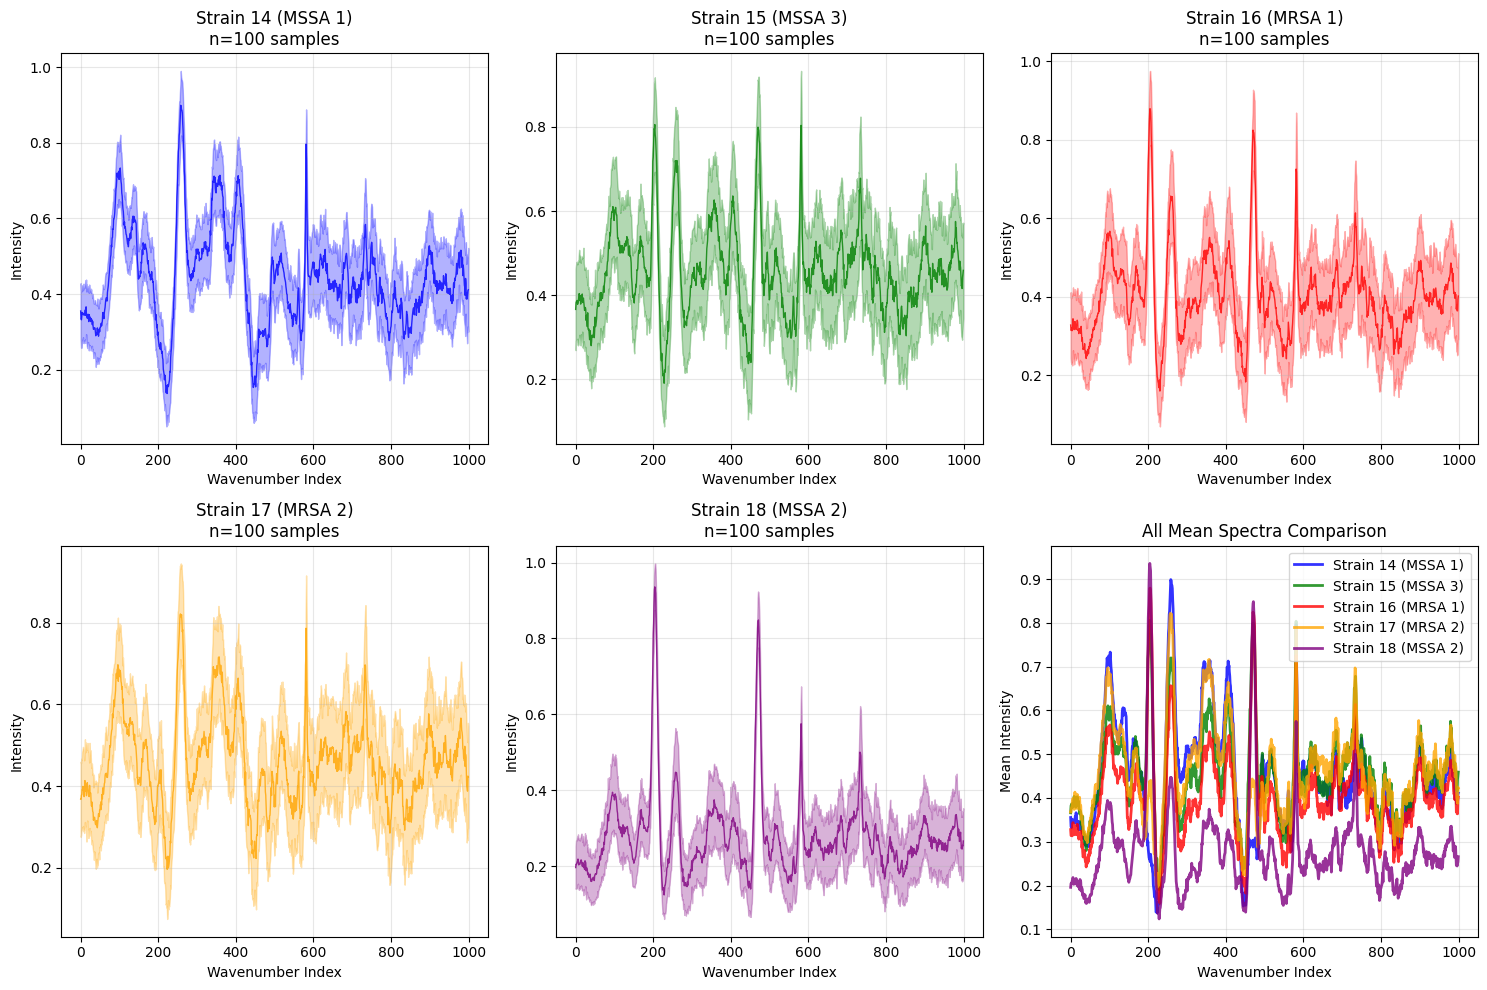


=== SPECTRAL CORRELATION ANALYSIS ===

Pairwise correlations between mean spectra:
Strain 14 vs Strain 15: 0.6164
Strain 14 vs Strain 16: 0.5148
Strain 14 vs Strain 17: 0.9239
Strain 14 vs Strain 18: 0.1843
Strain 15 vs Strain 16: 0.9717
Strain 15 vs Strain 17: 0.7554
Strain 15 vs Strain 18: 0.8506
Strain 16 vs Strain 17: 0.6624
Strain 16 vs Strain 18: 0.9177
Strain 17 vs Strain 18: 0.3741

=== MSSA vs MRSA GROUP ANALYSIS ===
MSSA group: 300 samples
MRSA group: 200 samples

MSSA vs MRSA group correlation: 0.9779
  CAUTION: MSSA and MRSA groups are very similar.
This may explain the moderate classification accuracy.


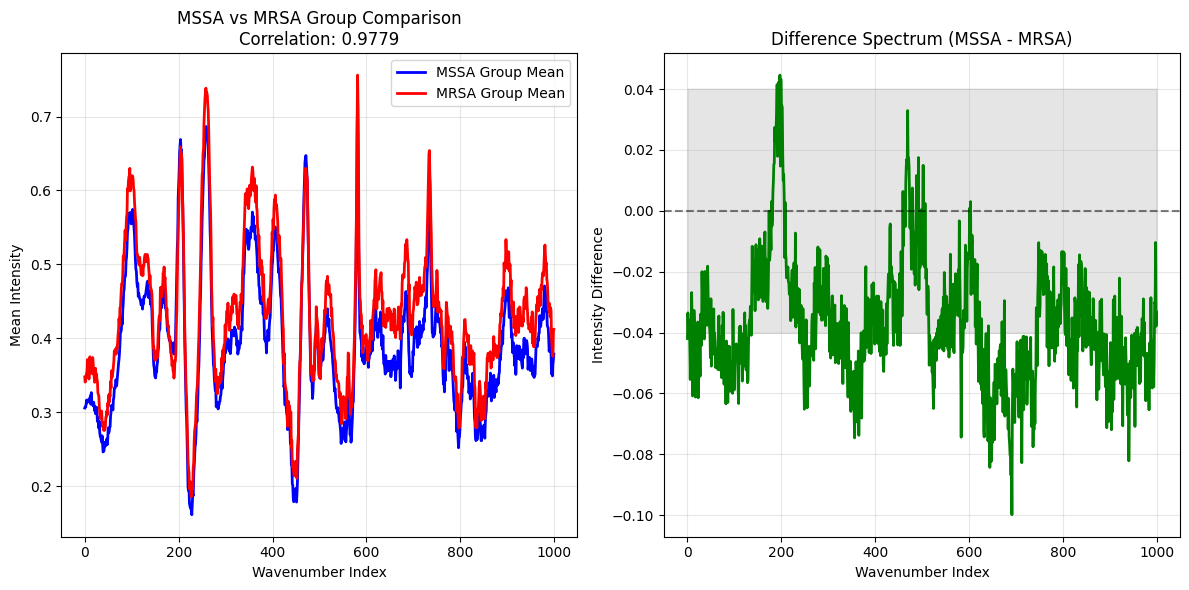


=== SUMMARY ===
Total test samples for 5 strains: 500
Strain distribution:
  Strain 14 (MSSA 1): 100 samples
  Strain 15 (MSSA 3): 100 samples
  Strain 16 (MRSA 1 (isogenic)): 100 samples
  Strain 17 (MRSA 2): 100 samples
  Strain 18 (MSSA 2): 100 samples


In [26]:

# Get the test data for the 5 strains
focused_strains = [14, 15, 16, 17, 18]  # MSSA and MRSA strains

# Filter test data for these strains
te_mask = np.isin(y_te, focused_strains)
X_te_focused = X_te[te_mask]
y_te_focused = y_te[te_mask]

print(f"Test data shapes:")
print(f"X_te_focused: {X_te_focused.shape}")
print(f"y_te_focused: {y_te_focused.shape}")

# Plot mean spectra for each strain
plt.figure(figsize=(15, 10))

colors = ['blue', 'green', 'red', 'orange', 'purple']
strain_names = ['MSSA 1', 'MSSA 3', 'MRSA 1', 'MRSA 2', 'MSSA 2']

for i, strain_id in enumerate(focused_strains):
    # Get data for this strain
    strain_mask = y_te_focused == strain_id
    strain_data = X_te_focused[strain_mask]

    if len(strain_data) > 0:
        # Calculate mean spectrum
        mean_spectrum = np.mean(strain_data, axis=0)
        std_spectrum = np.std(strain_data, axis=0)

        # Plot mean spectrum
        plt.subplot(2, 3, i+1)
        plt.plot(mean_spectrum, color=colors[i], linewidth=1, alpha=0.8)
        plt.fill_between(range(len(mean_spectrum)),
                        mean_spectrum - std_spectrum,
                        mean_spectrum + std_spectrum,
                        alpha=0.3, color=colors[i])
        plt.title(f'Strain {strain_id} ({strain_names[i]})\nn={len(strain_data)} samples')
        plt.xlabel('Wavenumber Index')
        plt.ylabel('Intensity')
        plt.grid(True, alpha=0.3)

# Plot all mean spectra together for comparison
plt.subplot(2, 3, 6)
for i, strain_id in enumerate(focused_strains):
    strain_mask = y_te_focused == strain_id
    strain_data = X_te_focused[strain_mask]

    if len(strain_data) > 0:
        mean_spectrum = np.mean(strain_data, axis=0)
        plt.plot(mean_spectrum, color=colors[i], linewidth=2,
                label=f'Strain {strain_id} ({strain_names[i]})', alpha=0.8)

plt.title('All Mean Spectra Comparison')
plt.xlabel('Wavenumber Index')
plt.ylabel('Mean Intensity')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlations between mean spectra
print("\n=== SPECTRAL CORRELATION ANALYSIS ===")
mean_spectra = {}
for i, strain_id in enumerate(focused_strains):
    strain_mask = y_te_focused == strain_id
    strain_data = X_te_focused[strain_mask]

    if len(strain_data) > 0:
        mean_spectra[strain_id] = np.mean(strain_data, axis=0)

# Calculate pairwise correlations
print("\nPairwise correlations between mean spectra:")
for i, strain1 in enumerate(focused_strains):
    for j, strain2 in enumerate(focused_strains):
        if i < j and strain1 in mean_spectra and strain2 in mean_spectra:
            corr = np.corrcoef(mean_spectra[strain1], mean_spectra[strain2])[0, 1]
            print(f"Strain {strain1} vs Strain {strain2}: {corr:.4f}")

# Calculate MSSA vs MRSA group correlations
print("\n=== MSSA vs MRSA GROUP ANALYSIS ===")
mssa_strains = [14, 15, 18]  # MSSA 1, 3, 2
mrsa_strains = [16, 17]       # MRSA 1, 2

# Calculate mean spectrum for MSSA group
mssa_data = []
for strain_id in mssa_strains:
    strain_mask = y_te_focused == strain_id
    if np.any(strain_mask):
        mssa_data.append(X_te_focused[strain_mask])

if mssa_data:
    mssa_combined = np.vstack(mssa_data)
    mssa_mean = np.mean(mssa_combined, axis=0)
    print(f"MSSA group: {len(mssa_combined)} samples")

# Calculate mean spectrum for MRSA group
mrsa_data = []
for strain_id in mrsa_strains:
    strain_mask = y_te_focused == strain_id
    if np.any(strain_mask):
        mrsa_data.append(X_te_focused[strain_mask])

if mrsa_data:
    mrsa_combined = np.vstack(mrsa_data)
    mrsa_mean = np.mean(mrsa_combined, axis=0)
    print(f"MRSA group: {len(mrsa_combined)} samples")

# Calculate correlation between MSSA and MRSA groups
if mssa_data and mrsa_data:
    group_corr = np.corrcoef(mssa_mean, mrsa_mean)[0, 1]
    print(f"\nMSSA vs MRSA group correlation: {group_corr:.4f}")

    if group_corr > 0.99:
        print("  WARNING: MSSA and MRSA groups are nearly identical!")
        print("This explains the low classification accuracy.")
    elif group_corr > 0.95:
        print("  CAUTION: MSSA and MRSA groups are very similar.")
        print("This may explain the moderate classification accuracy.")
    else:
        print(" MSSA and MRSA groups show some differences.")
        print("Classification should be possible with better methods.")

# Plot MSSA vs MRSA comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
if mssa_data and mrsa_data:
    plt.plot(mssa_mean, color='blue', linewidth=2, label='MSSA Group Mean')
    plt.plot(mrsa_mean, color='red', linewidth=2, label='MRSA Group Mean')
    plt.title(f'MSSA vs MRSA Group Comparison\nCorrelation: {group_corr:.4f}')
    plt.xlabel('Wavenumber Index')
    plt.ylabel('Mean Intensity')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if mssa_data and mrsa_data:
    # Plot difference spectrum
    diff_spectrum = mssa_mean - mrsa_mean
    plt.plot(diff_spectrum, color='green', linewidth=2)
    plt.title('Difference Spectrum (MSSA - MRSA)')
    plt.xlabel('Wavenumber Index')
    plt.ylabel('Intensity Difference')
    plt.grid(True, alpha=0.3)

    # Highlight significant differences
    threshold = np.std(diff_spectrum) * 2
    significant_diffs = np.abs(diff_spectrum) > threshold
    plt.fill_between(range(len(diff_spectrum)),
                    -threshold, threshold,
                    alpha=0.2, color='gray', label=f'±2σ threshold')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Total test samples for 5 strains: {len(X_te_focused)}")
print(f"Strain distribution:")
for strain_id in focused_strains:
    count = np.sum(y_te_focused == strain_id)
    strain_name = STRAINS[strain_id]
    print(f"  Strain {strain_id} ({strain_name}): {count} samples")

In [27]:
STRAIN_ORDER = np.arange(30)
sid_ref_all = np.repeat(STRAIN_ORDER, 2000)
sid_te_all  = np.repeat(STRAIN_ORDER, 100)

focused_strains = get_hierarchical_strains()
# Create hierarchical class mapping
HIERARCHICAL_TO_BIN = {0: 0, 1: 1}  # MSSA=0, MRSA=1
BIN_TO_HIERARCHICAL = {0: 0, 1: 1}

# Filter data for hierarchical classification
# ref_mask = np.isin(sid_ref_all, focused_strains)
# te_mask = np.isin(sid_te_all, focused_strains)

ref_mask = np.isin(y_ref, focused_strains)
te_mask  = np.isin(y_te,  focused_strains)

sid_ref_filtered = sid_ref_all[ref_mask]
sid_te_filtered = sid_te_all[te_mask]

X_ref_filtered = X_ref[ref_mask]
X_te_filtered = X_te[te_mask]

# Create hierarchical labels
y_ref_filtered = np.array([HIERARCHICAL_TO_BIN[HIERARCHICAL_GROUPINGS[s]] for s in sid_ref_filtered], dtype=int)
y_te_filtered = np.array([HIERARCHICAL_TO_BIN[HIERARCHICAL_GROUPINGS[s]] for s in sid_te_filtered], dtype=int)

print(f"\nHierarchical classification data shapes:")
print(f"X_ref_filtered: {X_ref_filtered.shape}")
print(f"y_ref_filtered: {y_ref_filtered.shape}")
print(f"X_te_filtered: {X_te_filtered.shape}")
print(f"y_te_filtered: {y_te_filtered.shape}")

# Show class distribution
print(f"\nClass distribution in hierarchical dataset:")
from collections import Counter
class_counts = Counter(y_ref_filtered)
for class_id, count in sorted(class_counts.items()):
    class_name = HIERARCHICAL_CLASSES[class_id]
    print(f"Class {class_id} ({class_name}): {count} samples")


Hierarchical classification data shapes:
X_ref_filtered: (10000, 1000)
y_ref_filtered: (10000,)
X_te_filtered: (500, 1000)
y_te_filtered: (500,)

Class distribution in hierarchical dataset:
Class 0 (MSSA): 6000 samples
Class 1 (MRSA): 4000 samples


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class RamanNetResidualBlock(nn.Module):
    """
    Residual block for RamanNet architecture as described in the paper.
    Each residual layer contains a shortcut connection between input and output
    of one convolutional layer.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(RamanNetResidualBlock, self).__init__()

        # Single convolutional layer as per paper description
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                             padding=kernel_size//2, bias=False)
        self.bn = nn.BatchNorm1d(out_channels)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        # FIXED: Use out = out + self.shortcut(x) instead of += to avoid in-place operation
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class BinaryClassifier(nn.Module):
    """
    BinaryClassifier model following the exact RamanNet architecture described in the paper.

    Architecture:
    1. Initial convolution layer (kernel size 7)
    2. Two residual layers (kernel sizes 7 and 3)
    3. Flatten layer
    4. Final fully connected classification layer (2 classes for binary classification)

    All convolution kernel numbers are set to 1 as specified in the paper.
    Uses kaiming normal initialization.
    """
    def __init__(self, input_dim=1000, n_classes=2):
        super(BinaryClassifier, self).__init__()
        self.input_dim = input_dim
        self.n_classes = n_classes

        # Initial convolution layer (kernel size 7, 1 channel)
        self.conv1 = nn.Conv1d(1, 1, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(1)

        # First residual layer (kernel size 7)
        self.residual1 = RamanNetResidualBlock(1, 1, kernel_size=7)

        # Second residual layer (kernel size 3)
        self.residual2 = RamanNetResidualBlock(1, 1, kernel_size=3)

        # Flatten layer
        self.flatten = nn.Flatten()

        # Final fully connected classification layer
        self.classifier = nn.Linear(input_dim, n_classes)

        # Initialize weights using kaiming normal initialization
        self._initialize_weights()

    def forward(self, x):
        # Initial convolution layer
        x = F.relu(self.bn1(self.conv1(x)))

        # Two residual layers
        x = self.residual1(x)
        x = self.residual2(x)

        # Flatten
        x = self.flatten(x)

        # Final classification layer
        x = self.classifier(x)

        return x

    def _initialize_weights(self):
        """
        Initialize weights using kaiming normal initialization as specified in the paper.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

In [29]:
def prepare_data(X, y, batch_size=32, shuffle=True):
    """Convert numpy arrays to DataLoader with shape [B,1,L]."""
    X_tensor = torch.as_tensor(X, dtype=torch.float32).unsqueeze(1)  # [N,1,L]
    y_tensor = torch.as_tensor(y, dtype=torch.long)
    dataset  = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

In [30]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad(set_to_none=True)
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        # sample-weighted loss to avoid bias from a short last batch
        bs = target.size(0)
        total_loss += loss.detach().item() * bs
        pred = output.detach().argmax(dim=1)
        correct += (pred == target).sum().item()
        total += bs

    avg_loss = total_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc

In [31]:
# Evaluation function
def evaluate(model, test_loader, criterion, device):
    model.eval()
    assert not model.training, "Model must be in eval() during evaluation."

    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)

            bs = target.size(0)
            total_loss += loss.detach().item() * bs
            pred = output.detach().argmax(dim=1)

            correct += (pred == target).sum().item()
            total += bs
            all_preds.extend(pred.cpu().tolist())
            all_targets.extend(target.cpu().tolist())

    avg_loss = total_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc, all_preds, all_targets

In [32]:
def train_eval_permutation_with_epochs(
    X_train, y_train, X_test, y_test,
    epochs=10, lr=1.5e-3, batch_size=256, weight_decay=1e-1
):

    torch.manual_seed(123)
    torch.cuda.manual_seed_all(123)

    # Infer spectrum length from data
    input_dim = X_train.shape[1]
    assert X_test.shape[1] == input_dim, "Train/Test spectrum length mismatch."

    # Model (RamanNet) + loaders
    model = BinaryClassifier(input_dim=input_dim, n_classes=2).to(DEVICE)
    train_loader = prepare_data(X_train, y_train, batch_size=batch_size, shuffle=True)
    test_loader  = prepare_data(X_test,  y_test,  batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_test_acc = -1.0
    best_epoch = -1
    best_state = None

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        running_correct, running_total, running_loss = 0, 0, 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)  # [B,1,L]
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.detach().item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)

        train_acc = 100.0 * running_correct / max(1, running_total)

        # ---- Eval ----
        model.eval()
        test_correct, test_total, test_loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                test_loss_sum += float(loss) * xb.size(0)
                preds = logits.argmax(dim=1)
                test_correct += (preds == yb).sum().item()
                test_total += xb.size(0)

        test_acc = 100.0 * test_correct / max(1, test_total)
        print(f"    Epoch {epoch}: Train Acc = {train_acc:.2f}%, Test Acc = {test_acc:.2f}%")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"[BEST] Epoch {best_epoch}: Test Acc = {best_test_acc:.2f}%")
    return best_test_acc / 100.0

In [33]:
LAST_PERM_MAP = None
from itertools import combinations


def generate_all_unique_permutations(focused_strains):
    """
    Generate all 10 unique ways to assign 3 strains to MSSA and 2 to MRSA
    """
    n_mssa = sum(HIERARCHICAL_GROUPINGS[s] == 0 for s in focused_strains)  # 3
    n_mrsa = sum(HIERARCHICAL_GROUPINGS[s] == 1 for s in focused_strains)  # 2

    # Generate all combinations of 3 strains for MSSA
    mssa_combinations = list(combinations(focused_strains, n_mssa))

    unique_permutations = []
    for mssa_strains in mssa_combinations:
        mrsa_strains = [s for s in focused_strains if s not in mssa_strains]

        # Create strain-to-label mapping
        strain_to_label = {}
        for strain in mssa_strains:
            strain_to_label[strain] = HIERARCHICAL_TO_BIN[0]  # MSSA = 0
        for strain in mrsa_strains:
            strain_to_label[strain] = HIERARCHICAL_TO_BIN[1]  # MRSA = 1

        unique_permutations.append(strain_to_label)

    return unique_permutations

def print_hierarchical_permutation_mapping(perm_idx, y_ref_perm, y_te_perm):
    print(f"\nPermutation {perm_idx}: strain -> hierarchical class (TRUE -> PERMUTED)")
    if LAST_PERM_MAP is None:
        print("  [warn] LAST_PERM_MAP is not set")
        return
    for sid in focused_strains:
        true_superclass = HIERARCHICAL_GROUPINGS[sid]
        perm_bin = LAST_PERM_MAP[sid]
        perm_superclass = BIN_TO_HIERARCHICAL[perm_bin]
        strain_name = STRAINS[sid]
        true_name = HIERARCHICAL_CLASSES[true_superclass]
        perm_name = HIERARCHICAL_CLASSES[perm_superclass]
        print(f"{sid:2d} | {strain_name:<20} : [{true_superclass}] {true_name}  ->  [{perm_superclass}] {perm_name}")

In [34]:
# Permutation test parameters
#N_PERMUTATIONS = 1000  # Number of permutations
PERM_EPOCHS = 10   # Epochs for each permutation
RANDOM_SEED =42

In [35]:
# Train with true hierarchical labels
print(f"\nTRUE hierarchical labels training:")
true_accuracy = train_eval_permutation_with_epochs(
    X_ref_filtered, y_ref_filtered,
    X_te_filtered, y_te_filtered,
    epochs=PERM_EPOCHS
)
print(f"TRUE hierarchical labels final accuracy: {true_accuracy:.2%}")


TRUE hierarchical labels training:


    Epoch 1: Train Acc = 65.72%, Test Acc = 66.80%
    Epoch 2: Train Acc = 80.90%, Test Acc = 68.60%
    Epoch 3: Train Acc = 83.80%, Test Acc = 66.20%
    Epoch 4: Train Acc = 85.38%, Test Acc = 69.00%
    Epoch 5: Train Acc = 86.89%, Test Acc = 68.80%
    Epoch 6: Train Acc = 87.19%, Test Acc = 69.00%
    Epoch 7: Train Acc = 87.78%, Test Acc = 67.60%
    Epoch 8: Train Acc = 87.55%, Test Acc = 67.20%
    Epoch 9: Train Acc = 87.39%, Test Acc = 70.40%
    Epoch 10: Train Acc = 88.04%, Test Acc = 70.00%
[BEST] Epoch 9: Test Acc = 70.40%
TRUE hierarchical labels final accuracy: 70.40%


In [36]:
import numpy as np, hashlib

def audit_id_correspondence(
    X_ref, y_ref, X_te, y_te,
    focused_strains,
    HIERARCHICAL_GROUPINGS, HIERARCHICAL_TO_BIN,
    unique_permutations=None,
    hash_stride=1,  # increase (e.g., 10) if arrays are huge to speed up leakage check
):
    # --- basic integrity ---
    assert len(X_ref) == len(y_ref) and len(X_te) == len(y_te), "X/y length mismatch."
    ref_set, te_set = set(np.unique(y_ref)), set(np.unique(y_te))
    fset = set(focused_strains)
    assert fset.issubset(ref_set), "Some focused strains missing from train."
    assert fset.issubset(te_set),  "Some focused strains missing from test."

    # --- masks from true labels (not synthetic ids) ---
    ref_mask = np.isin(y_ref, focused_strains)
    te_mask  = np.isin(y_te,  focused_strains)

    sid_ref_filtered = y_ref[ref_mask]  # strain IDs per sample (train)
    sid_te_filtered  = y_te[te_mask]    # strain IDs per sample (test)

    # --- canonical strain->bin mapping ---
    strain_to_bin = {s: HIERARCHICAL_TO_BIN[HIERARCHICAL_GROUPINGS[s]] for s in focused_strains}
    y_ref_bin_a = np.array([strain_to_bin[s] for s in sid_ref_filtered], dtype=int)
    y_te_bin_a  = np.array([strain_to_bin[s] for s in sid_te_filtered],  dtype=int)

    # vectorized cross-check (same result via direct y_* lookups)
    y_ref_bin_b = np.vectorize(strain_to_bin.get)(y_ref[ref_mask])
    y_te_bin_b  = np.vectorize(strain_to_bin.get)(y_te[te_mask])
    assert np.array_equal(y_ref_bin_a, y_ref_bin_b), "Train mapping inconsistency."
    assert np.array_equal(y_te_bin_a,  y_te_bin_b),  "Test mapping inconsistency."

    # both classes present in each split
    assert set(np.unique(y_ref_bin_a)) == {0, 1}, "Train missing a class."
    assert set(np.unique(y_te_bin_a))  == {0, 1}, "Test missing a class."

    # --- optional: prove permutations apply identically to both splits ---
    if unique_permutations is not None:
        for i, perm in enumerate(unique_permutations, 1):
            yref_perm_a = np.array([perm[s] for s in sid_ref_filtered], dtype=int)
            yte_perm_a  = np.array([perm[s] for s in sid_te_filtered],  dtype=int)

            yref_perm_b = np.vectorize(perm.get)(y_ref[ref_mask])
            yte_perm_b  = np.vectorize(perm.get)(y_te[te_mask])

            assert np.array_equal(yref_perm_a, yref_perm_b), f"Perm {i}: train mismatch."
            assert np.array_equal(yte_perm_a,  yte_perm_b),  f"Perm {i}: test mismatch."
            assert set(np.unique(yref_perm_a)) == {0,1},     f"Perm {i}: train missing a class."
            assert set(np.unique(yte_perm_a))  == {0,1},     f"Perm {i}: test missing a class."

    # --- leakage check: no identical samples across splits (by content hash) ---
    def row_hashes(X, stride):
        # ensure contiguous for stable bytes view
        return {
            hashlib.sha1(np.ascontiguousarray(x).tobytes()).hexdigest()
            for x in X[::stride]
        }
    overlap = row_hashes(X_ref, hash_stride) & row_hashes(X_te, hash_stride)
    assert len(overlap) == 0, f"Potential leakage: {len(overlap)} duplicate samples across splits."

    print("ID correspondence OK: focused strains exist in both splits; "
          "mapping consistent (incl. permutations if provided); "
          "both classes present; no leakage detected.")


In [37]:

null_accuracies = []


ref_strains_order = sid_ref_filtered
te_strains_order = sid_te_filtered

# Generate all unique permutations
unique_permutations = generate_all_unique_permutations(focused_strains)

audit_id_correspondence(X_ref, y_ref, X_te, y_te,
    focused_strains,
    HIERARCHICAL_GROUPINGS, HIERARCHICAL_TO_BIN,
    unique_permutations=unique_permutations,
    hash_stride=1)

for perm_idx, strain_to_label in enumerate(unique_permutations, 1):
    # Apply the same mapping to both splits
    y_ref_permuted = np.array([strain_to_label[s] for s in ref_strains_order], dtype=int)
    y_te_permuted = np.array([strain_to_label[s] for s in te_strains_order], dtype=int)

    for name, y in [('ref', y_ref_permuted), ('te', y_te_permuted)]:
      classes, cnts = np.unique(y, return_counts=True)
      assert len(classes) == 2, f"{name} missing a class in this permutation"
      print(name, dict(zip(classes, cnts)))

    # Print the mapping
    print(f"\nPermutation {perm_idx}: strain -> hierarchical class (TRUE -> PERMUTED)")
    for sid in focused_strains:
        true_superclass = HIERARCHICAL_GROUPINGS[sid]
        perm_bin = strain_to_label[sid]
        perm_superclass = BIN_TO_HIERARCHICAL[perm_bin]
        strain_name = STRAINS[sid]
        true_name = HIERARCHICAL_CLASSES[true_superclass]
        perm_name = HIERARCHICAL_CLASSES[perm_superclass]
        print(f"{sid:2d} | {strain_name:<20} : [{true_superclass}] {true_name}  ->  [{perm_superclass}] {perm_name}")

    # Train & evaluate with permuted labels
    print(f"\nPermutation {perm_idx} training:")
    perm_accuracy = train_eval_permutation_with_epochs(
        X_ref_filtered, y_ref_permuted,
        X_te_filtered, y_te_permuted,
        epochs=PERM_EPOCHS
    )
    null_accuracies.append(perm_accuracy)
    print(f"Permutation {perm_idx} final accuracy: {perm_accuracy:.2%}")

print("Unique hierarchical permutation test completed!")

ID correspondence OK: focused strains exist in both splits; mapping consistent (incl. permutations if provided); both classes present; no leakage detected.
ref {np.int64(0): np.int64(6000), np.int64(1): np.int64(4000)}
te {np.int64(0): np.int64(300), np.int64(1): np.int64(200)}

Permutation 1: strain -> hierarchical class (TRUE -> PERMUTED)
14 | MSSA 1               : [0] MSSA  ->  [0] MSSA
15 | MSSA 3               : [0] MSSA  ->  [0] MSSA
16 | MRSA 1 (isogenic)    : [1] MRSA  ->  [0] MSSA
17 | MRSA 2               : [1] MRSA  ->  [1] MRSA
18 | MSSA 2               : [0] MSSA  ->  [1] MRSA

Permutation 1 training:
    Epoch 1: Train Acc = 73.54%, Test Acc = 63.80%
    Epoch 2: Train Acc = 84.42%, Test Acc = 70.80%
    Epoch 3: Train Acc = 87.93%, Test Acc = 63.20%
    Epoch 4: Train Acc = 88.86%, Test Acc = 66.00%
    Epoch 5: Train Acc = 90.15%, Test Acc = 61.40%
    Epoch 6: Train Acc = 90.91%, Test Acc = 62.40%
    Epoch 7: Train Acc = 91.41%, Test Acc = 58.40%
    Epoch 8: Train A

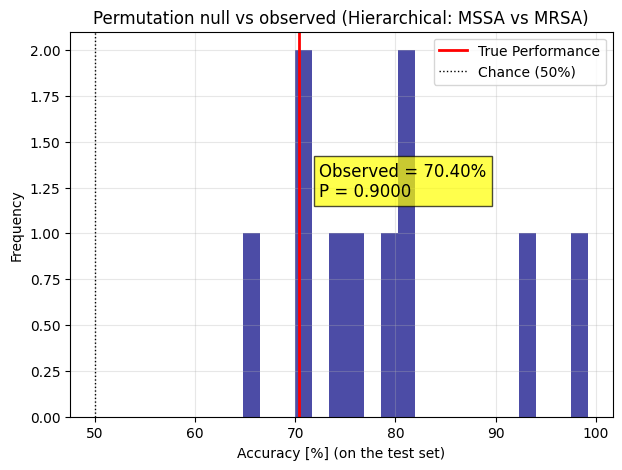

In [38]:
# Create histogram visualization for hierarchical permutation test
null_accuracies = np.array(null_accuracies)

plt.figure(figsize=(7, 5))
plt.hist(null_accuracies * 100, bins=20, color='navy', alpha=0.7)

# Observed performance line
plt.axvline(true_accuracy * 100, color='red', linewidth=2, label='True Performance')

# Chance baseline for binary classification = 50%
plt.axvline(50, color='k', linestyle=':', linewidth=1, label='Chance (50%)')

plt.xlabel("Accuracy [%] (on the test set)")
plt.ylabel("Frequency")
plt.title("Permutation null vs observed (Hierarchical: MSSA vs MRSA)")

# Add text annotation with observed accuracy and permutation p-value
ymax = max(np.histogram(null_accuracies * 100, bins=20)[0])
p_value = np.mean(null_accuracies >= true_accuracy)

plt.text(true_accuracy * 100 + 2, ymax * 0.6,
         f"Observed = {true_accuracy * 100:.2f}%\nP = {p_value:.4f}",
         fontsize=12, bbox=dict(facecolor='yellow', alpha=0.7))

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
import math

def sampling_combinations(arr):
    n = len(null_accuracies)
    print(f"Array size: {n}\n")

    print("Without replacement (unordered combinations):")
    for k in range(1, n + 1):
        c = math.comb(n, k)
        print(f"  k={k}: {c}")

    print("\nWith replacement (unordered combinations):")
    for k in range(1, n + 1):
        c = math.comb(n + k - 1, k)
        print(f"  k={k}: {c}")

In [40]:
from itertools import combinations, combinations_with_replacement

def index_combos_by_k(arr):
    """
    Return two tables (lists) of index-combinations for k=1..n:
      - without_rep[k]: all k-combos of indices without replacement
      - with_rep[k]   : all k-combos of indices with replacement (non-decreasing)
    Each table has length n+1 with index 0 unused (None).
    """
    n = len(arr)
    idx = range(n)

    without_rep = [None] * (n + 1)
    with_rep    = [None] * (n + 1)

    for k in range(1, n + 1):
        without_rep[k] = [list(t) for t in combinations(idx, k)]
        with_rep[k]    = [list(t) for t in combinations_with_replacement(idx, k)]

    return without_rep, with_rep

In [41]:
without_rep, with_rep = index_combos_by_k(null_accuracies)

# Example: all 3-index combos without replacement
print("k=2, without replacement:", without_rep[2])   # [[0,1,2],[0,1,3],[0,2,3],[1,2,3]]
# Example: all 3-index combos with replacement
print("k=2, with replacement:", with_rep[2])         # [[0,0,0],[0,0,1],...,[1,3,3],[2,2,2],[2,2,3],[2,3,3],[3,3,3]]

# If you want the actual element combos from indices:
elem_combos_k2 = [[null_accuracies[i] for i in combo] for combo in without_rep[2]]
print("k=2 element combos (no repl.):", elem_combos_k2)

k=2, without replacement: [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [0, 8], [0, 9], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [1, 7], [1, 8], [1, 9], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [2, 8], [2, 9], [3, 4], [3, 5], [3, 6], [3, 7], [3, 8], [3, 9], [4, 5], [4, 6], [4, 7], [4, 8], [4, 9], [5, 6], [5, 7], [5, 8], [5, 9], [6, 7], [6, 8], [6, 9], [7, 8], [7, 9], [8, 9]]
k=2, with replacement: [[0, 0], [0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [0, 8], [0, 9], [1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [1, 7], [1, 8], [1, 9], [2, 2], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [2, 8], [2, 9], [3, 3], [3, 4], [3, 5], [3, 6], [3, 7], [3, 8], [3, 9], [4, 4], [4, 5], [4, 6], [4, 7], [4, 8], [4, 9], [5, 5], [5, 6], [5, 7], [5, 8], [5, 9], [6, 6], [6, 7], [6, 8], [6, 9], [7, 7], [7, 8], [7, 9], [8, 8], [8, 9], [9, 9]]
k=2 element combos (no repl.): [[np.float64(0.708), np.float64(0.9259999999999999)], [np.float64(0.708), np.float64(0.7040000000000001)], [np.float64

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def pval_stats_by_k(null_accuracies, true_accuracy, combos_by_k, sample_limit=None, rng=None, ddof=1):
    """
    Compute per-k stats of the 'p-value' for each combo:
      p(combo) = (# elements in combo >= true_accuracy) / k

    combos_by_k may be:
      - dict[int, list[tuple[int]]]
      - list/tuple of length n+1 with index 0 unused (None), i.e., combos_by_k[k] for k>=1
    """
    if rng is None:
        rng = np.random.default_rng(0)

    arr = np.asarray(null_accuracies)
    thr = true_accuracy

    ks, ns, pmins, pmaxs, pmeans, pmeds, pstds = [], [], [], [], [], [], []

    def _iter_k_combos(cbk):
        # Accept dict OR 1-indexed list/tuple
        if isinstance(cbk, dict):
            for k in sorted(cbk.keys()):
                yield k, cbk[k]
        else:
            # assume sequence with index 0 unused
            for k in range(1, len(cbk)):
                yield k, cbk[k]

    for k, combos in _iter_k_combos(combos_by_k):
        if combos is None or len(combos) == 0:
            continue

        # Optional uniform downsampling of combos for large cases
        if (sample_limit is not None) and (len(combos) > sample_limit):
            idxs = rng.choice(len(combos), size=sample_limit, replace=False)
            combos = [combos[i] for i in idxs]

        # Vectorized counting
        idx = np.asarray(combos, dtype=int)  # shape (m, k_expected)
        if idx.ndim != 2 or idx.shape[1] != k:
            raise ValueError(f"All combos for k={k} must be sequences of length {k}.")
        if idx.size:  # bounds check
            if idx.min() < 0 or idx.max() >= arr.size:
                raise IndexError(
                    f"Combo indices out of bounds for null_accuracies of length {arr.size}."
                )

        counts = (arr[idx] >= thr).sum(axis=1)
        pvals = counts / float(k)

        ks.append(k)
        ns.append(pvals.size)
        pmins.append(pvals.min())
        pmaxs.append(pvals.max())
        pmeans.append(pvals.mean())
        pmeds.append(np.median(pvals))
        pstds.append(pvals.std(ddof=ddof))

    return {
        "k": np.array(ks, dtype=int),
        "n": np.array(ns, dtype=int),
        "p_min": np.array(pmins, dtype=float),
        "p_max": np.array(pmaxs, dtype=float),
        "p_mean": np.array(pmeans, dtype=float),
        "p_median": np.array(pmeds, dtype=float),
        "p_std": np.array(pstds, dtype=float),  # SD across combos
    }


import numpy as np
import matplotlib.pyplot as plt

def plot_pval_stats(
    flipped=True,
    stats_without=None,
    stats_with=None,
    save_path=None,
    dpi=300,
    band="se",
    fit="tight",          # 'tight' (auto-fit with padding), 'unit' (clamp to [0,1]), or None (matplotlib auto)
    pad_frac=0.05,        # fractional padding around data limits when fit='tight'
    clip_unit=True,       # clamp p-value bands to [0,1] before computing limits
):
    """
    Plot per-k stats; supports side-by-side plots if both stats_* provided.

    band: 'se' = ±1 standard error around mean (default), 'sd' = ±1 standard deviation.
    fit:
      - 'tight' -> compute limits from the data (zoom to fit) with small padding.
      - 'unit'  -> clamp the p-value axis to [0,1] like before.
      - None    -> let matplotlib autoscale (no manual limits).
    """

    if (stats_without is None) and (stats_with is None):
        raise ValueError("Provide at least one of stats_without or stats_with")

    def _apply_fit(ax, x_all, y_all):
        # flatten and drop NaNs
        xv = np.asarray(x_all).ravel()
        yv = np.asarray(y_all).ravel()
        xv = xv[~np.isnan(xv)]
        yv = yv[~np.isnan(yv)]
        if fit is None:
            ax.relim()
            ax.autoscale(enable=True, axis="both", tight=True)
            ax.margins(pad_frac, pad_frac)
            return

        if fit == "tight":
            # pad both axes
            x_min, x_max = (np.min(xv), np.max(xv)) if xv.size else (0, 1)
            y_min, y_max = (np.min(yv), np.max(yv)) if yv.size else (0, 1)
            dx = max(x_max - x_min, 1e-9)
            dy = max(y_max - y_min, 1e-9)
            ax.set_xlim(x_min - pad_frac * dx, x_max + pad_frac * dx)
            ax.set_ylim(y_min - pad_frac * dy, y_max + pad_frac * dy)
        elif fit == "unit":
            # keep p-value axis in [0,1]; other axis gets tight limits with padding
            # Decide which axis is p-value based on orientation
            pass  # handled inline in each orientation below
        else:
            raise ValueError("fit must be 'tight', 'unit', or None")

    def _one(ax, stats, title):
        if flipped:
            # k on x; p on y
            x_k    = np.asarray(stats["k"])
            p_mean = np.asarray(stats["p_mean"])
            p_med  = np.asarray(stats["p_median"])
            p_max  = np.asarray(stats["p_max"])
            std    = np.asarray(stats["p_std"])
            n      = np.maximum(np.asarray(stats["n"]), 1)

            spread = std / np.sqrt(n) if band == "se" else std
            band_label = "±1 SE (mean)" if band == "se" else "±1 SD (across combos)"

            low  = p_mean - spread
            high = p_mean + spread
            if clip_unit:
                low  = np.clip(low,  0.0, 1.0)
                high = np.clip(high, 0.0, 1.0)

            ax.plot(x_k, p_mean, "-", label="mean")
            ax.plot(x_k, p_max, "--", label="max")
            ax.plot(x_k, p_med, "D", label="median")
            ax.fill_between(x_k, low, high, alpha=0.2, label=band_label)
            ax.set_xlabel("k")
            ax.set_ylabel("p-value")
            ax.set_xticks(x_k)

            if fit == "unit":
                # p-axis fixed to [0,1], k fits tightly with half-step padding
                ax.set_ylim(0, 1)
                ax.set_xlim(np.min(x_k) - 0.5, np.max(x_k) + 0.5)
            else:
                # tight fit on both axes
                _apply_fit(ax, x_k, np.concatenate([p_mean, p_med, p_max, low, high]))
                # keep nice tick coverage on discrete k
                ax.set_xlim(np.min(x_k) - 0.5, np.max(x_k) + 0.5)

        else:
            # p on x; k on y  (fixed a bug: previously x/y were swapped here)
            k      = np.asarray(stats["k"])
            p_mean = np.asarray(stats["p_mean"])
            p_med  = np.asarray(stats["p_median"])
            p_max  = np.asarray(stats["p_max"])
            std    = np.asarray(stats["p_std"])
            n      = np.maximum(np.asarray(stats["n"]), 1)

            spread = std / np.sqrt(n) if band == "se" else std
            band_label = "±1 SE (mean)" if band == "se" else "±1 SD (across combos)"

            low  = p_mean - spread
            high = p_mean + spread
            if clip_unit:
                low  = np.clip(low,  0.0, 1.0)
                high = np.clip(high, 0.0, 1.0)

            ax.plot(p_mean, k, "-", label="mean")
            ax.plot(p_max,  k, "--", label="max")
            ax.plot(p_med,  k, "D", label="median")
            ax.fill_betweenx(k, low, high, alpha=0.2, label=band_label)
            ax.set_ylabel("k")
            ax.set_xlabel("p-value")
            ax.set_yticks(k)

            if fit == "unit":
                ax.set_xlim(0, 1)
                ax.set_ylim(np.min(k) - 0.5, np.max(k) + 0.5)
            else:
                _apply_fit(ax, np.concatenate([p_mean, p_med, p_max, low, high]), k)
                ax.set_ylim(np.min(k) - 0.5, np.max(k) + 0.5)

        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    if (stats_without is not None) and (stats_with is not None):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True if flipped else False)
        _one(axes[0], stats_without, "Without replacement")
        _one(axes[1], stats_with, "With replacement")
    else:
        fig, ax = plt.subplots(figsize=(6, 5))
        stats = stats_without if stats_without is not None else stats_with
        which = "Without replacement" if stats_without is not None else "With replacement"
        _one(ax, stats, which)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi)
        plt.close()
    else:
        plt.show()

In [43]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator, FuncFormatter

# # ---------- helpers for consistent styling ----------
# def _arr(stats, keys, fallback_len=None, default=None):
#     """Return first present key as np.array; else default/fallback."""
#     for k in keys:
#         if k in stats and stats[k] is not None:
#             return np.asarray(stats[k])
#     if fallback_len is not None:
#         return np.full(fallback_len, default)
#     return None

# def _k_from_stats(stats):
#     if "k" in stats and stats["k"] is not None:
#         return np.asarray(stats["k"])
#     L = len(stats.get("p_mean", []))
#     return np.arange(1, L + 1)

# def _band_values(std, n, band="se"):
#     if std is None:
#         return None
#     if band == "se" and n is not None:
#         return std / np.sqrt(n)
#     return std  # 'sd' or missing n

# # ---------- stats (same logic, but add alias 'n_per_k' for convenience) ----------
# def pval_stats_by_k(null_accuracies, true_accuracy, combos_by_k, sample_limit=None, rng=None, ddof=1):
#     """
#     Compute per-k stats of the 'p-value' for each combo:
#       p(combo) = (# elements in combo >= true_accuracy) / k

#     combos_by_k may be:
#       - dict[int, list[tuple[int]]]
#       - list/tuple of length n+1 with index 0 unused (None), i.e., combos_by_k[k] for k>=1
#     """
#     if rng is None:
#         rng = np.random.default_rng(0)

#     arr = np.asarray(null_accuracies)
#     thr = true_accuracy

#     ks, ns, pmins, pmaxs, pmeans, pmeds, pstds = [], [], [], [], [], [], []

#     def _iter_k_combos(cbk):
#         # Accept dict OR 1-indexed list/tuple
#         if isinstance(cbk, dict):
#             for k in sorted(cbk.keys()):
#                 yield k, cbk[k]
#         else:
#             # assume sequence with index 0 unused
#             for k in range(1, len(cbk)):
#                 yield k, cbk[k]

#     for k, combos in _iter_k_combos(combos_by_k):
#         if combos is None or len(combos) == 0:
#             continue

#         # Optional uniform downsampling of combos for large cases
#         if (sample_limit is not None) and (len(combos) > sample_limit):
#             idxs = rng.choice(len(combos), size=sample_limit, replace=False)
#             combos = [combos[i] for i in idxs]

#         # Vectorized counting
#         idx = np.asarray(combos, dtype=int)  # shape (m, k_expected)
#         if idx.ndim != 2 or idx.shape[1] != k:
#             raise ValueError(f"All combos for k={k} must be sequences of length {k}.")
#         if idx.size:  # bounds check
#             if idx.min() < 0 or idx.max() >= arr.size:
#                 raise IndexError(
#                     f"Combo indices out of bounds for null_accuracies of length {arr.size}."
#                 )

#         counts = (arr[idx] >= thr).sum(axis=1)
#         pvals = counts / float(k)

#         ks.append(k)
#         ns.append(pvals.size)
#         pmins.append(float(np.min(pvals)))
#         pmaxs.append(float(np.max(pvals)))
#         pmeans.append(float(np.mean(pvals)))
#         pmeds.append(float(np.median(pvals)))
#         pstds.append(float(np.std(pvals, ddof=ddof)))

#     out = {
#         "k":        np.array(ks, dtype=int),
#         "n":        np.array(ns, dtype=int),
#         "p_min":    np.array(pmins, dtype=float),
#         "p_max":    np.array(pmaxs, dtype=float),
#         "p_mean":   np.array(pmeans, dtype=float),
#         "p_median": np.array(pmeds, dtype=float),
#         "p_std":    np.array(pstds, dtype=float),  # SD across combos
#     }
#     # Alias used by the styled plotter
#     out["n_per_k"] = out["n"]
#     return out

# # ---------- styled plotter (keeps your two-panel option & 'flipped' support) ----------
# def plot_pval_stats(
#     *,
#     flipped=True,            # True: k on x, p on y (recommended); False: p on x, k on y
#     stats_without=None,
#     stats_with=None,
#     title_left="Without replacement",
#     title_right="With replacement",
#     band="se",               # 'se' (±1 standard error) or 'sd' (±1 std)
#     y_zoom=None,             # e.g., (0.0, 0.2) when flipped=True; if flipped=False this applies to x (p-axis)
#     x_tick_step=500,         # ticks every N k-steps when flipped=True
#     save_path=None,
#     dpi=300
# ):
#     if (stats_without is None) and (stats_with is None):
#         raise ValueError("Provide at least one of stats_without or stats_with")

#     def _one(ax, stats, title):
#         # Pull fields with graceful fallbacks (matches your plot_pval_lines style)
#         k        = _k_from_stats(stats)
#         p_mean   = _arr(stats, ["p_mean", "mean"])
#         p_median = _arr(stats, ["p_median", "median"], fallback_len=len(k), default=np.nan)
#         p_std    = _arr(stats, ["p_std", "std"],       fallback_len=len(k), default=np.nan)
#         n_per_k  = _arr(stats, ["n_per_k", "n"])

#         p_min    = _arr(stats, ["p_min", "min", "p_lo", "lo"])
#         p_max    = _arr(stats, ["p_max", "max", "p_hi", "hi"])

#         band_vals = _band_values(p_std, n_per_k, band=band)
#         y_lo = p_mean - band_vals if band_vals is not None else None
#         y_hi = p_mean + band_vals if band_vals is not None else None

#         # Styled lines
#         if flipped:
#             # k on x; p on y
#             ax.plot(k, p_mean,   linewidth=2.0,               label="mean")
#             if p_median is not None and not np.all(np.isnan(p_median)):
#                 ax.plot(k, p_median, linewidth=1.8, linestyle="--", label="median")
#             if p_min is not None:
#                 ax.plot(k, p_min,    linewidth=1.2, linestyle=":",  alpha=0.8, label="min")
#             if p_max is not None:
#                 ax.plot(k, p_max,    linewidth=1.2, linestyle="-.", alpha=0.9, label="max")
#             if y_lo is not None and y_hi is not None:
#                 ax.fill_between(k, y_lo, y_hi, alpha=0.18, label=f"±1 {band.upper()}")

#             ax.set_title(title)
#             ax.set_xlabel("k (combination size)")
#             ax.set_ylabel("p-value")

#             # Limits & ticks
#             ax.set_xlim(k.min(), k.max())
#             if y_zoom is not None:
#                 ax.set_ylim(*y_zoom)
#             if len(k) > 1:
#                 ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))
#                 ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):d}"))
#         else:
#             # p on x; k on y  (apply same styling; y_zoom acts on p-axis here)
#             ax.plot(p_mean,   k, linewidth=2.0,               label="mean")
#             if p_median is not None and not np.all(np.isnan(p_median)):
#                 ax.plot(p_median, k, linewidth=1.8, linestyle="--", label="median")
#             if p_min is not None:
#                 ax.plot(p_min,    k, linewidth=1.2, linestyle=":",  alpha=0.8, label="min")
#             if p_max is not None:
#                 ax.plot(p_max,    k, linewidth=1.2, linestyle="-.", alpha=0.9, label="max")
#             if y_lo is not None and y_hi is not None:
#                 ax.fill_betweenx(k, y_lo, y_hi, alpha=0.18, label=f"±1 {band.upper()}")

#             ax.set_title(title)
#             ax.set_ylabel("k (combination size)")
#             ax.set_xlabel("p-value")

#             ax.set_ylim(k.min(), k.max())
#             if y_zoom is not None:
#                 ax.set_xlim(*y_zoom)

#         # Grid/legend to match style
#         ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
#         ax.legend(loc="best", frameon=False)

#     # Figure layout: single or side-by-side
#     if (stats_without is not None) and (stats_with is not None):
#         share = {"sharey": True} if flipped else {"sharex": True}
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), **share)
#         _one(axes[0], stats_without, title_left)
#         _one(axes[1], stats_with,    title_right)
#     else:
#         fig, ax = plt.subplots(figsize=(8.5, 4.8))
#         stats = stats_without if stats_without is not None else stats_with
#         which = title_left if stats_without is not None else title_right
#         _one(ax, stats, which)

#     if save_path:
#         os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
#         fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
#         plt.close(fig)
#     else:
#         plt.show()
#     return fig


In [44]:
stats_wout = pval_stats_by_k(null_accuracies, true_accuracy, without_rep)
stats_with = pval_stats_by_k(null_accuracies, true_accuracy, with_rep)
plot_pval_stats(stats_without=stats_wout, stats_with=stats_with, save_path="./pvalues_by_k.png", dpi=300)